In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
print("Loading data..")

try:
    df = pd.read_csv('IMDB_Dataset.csv')
    print("Data loaded successfully")
except FileNotFoundError:
    print("ERROR: 'IMDB_Dataset.csv' not found.")
    print("Please make sure it is in the same folder as your notebook.")

# Vitals Check: What does the data look like?
print("\n--- First 5 Rows (df.head()) ---")
print(df.head())

# Vitals Check: What's in the data?
print("\n--- Data Info (df.info()) ---")
df.info()

# Vitals Check: How large is the data?
print(f"\nDataset shape: {df.shape}")
print(f"This means we have {df.shape[0]} rows (reviews) and {df.shape[1]} columns (sentiments).")


Loading data..
Data loaded successfully

--- First 5 Rows (df.head()) ---
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

--- Data Info (df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Dataset shape: (50000, 2)
This means we have 50000 rows (reviews) and 2 columns (sentiments).


In [4]:
# Data Cleaning: Check for duplicates
print("\n--- Checking for Duplicates (df.duplicated().sum()) ---")
duplicate_count = df.duplicated().sum()
print(f"Found {duplicate_count} duplicate rows.")

if duplicate_count > 0:
    print("Dropping duplicate rows...")
    df = df.drop_duplicates()
    print("Duplicates dropped.")
    print(f"New dataset shape: {df.shape}")


--- Checking for Duplicates (df.duplicated().sum()) ---
Found 418 duplicate rows.
Dropping duplicate rows...
Duplicates dropped.
New dataset shape: (49582, 2)


In [5]:
# Target Variable Check: Investigate 'sentiment'
print("\n--- Investigating Target Variable ('sentiment') ---")

# Check for typos or weird values
print("Unique sentiment values:")
print(df['sentiment'].unique())

# Check the balance
print("\nSentiment balance (value_counts()):")
print(df['sentiment'].value_counts(normalize=True))


--- Investigating Target Variable ('sentiment') ---
Unique sentiment values:
['positive' 'negative']

Sentiment balance (value_counts()):
sentiment
positive    0.501876
negative    0.498124
Name: proportion, dtype: float64



--- Investigating Feature ('review') ---
Statistics for review length (df['review_length'].describe()):
count    49582.000000
mean      1310.568230
std        990.762238
min         32.000000
25%        699.000000
50%        971.000000
75%       1592.000000
max      13704.000000
Name: review_length, dtype: float64

Plotting histogram of review lengths...


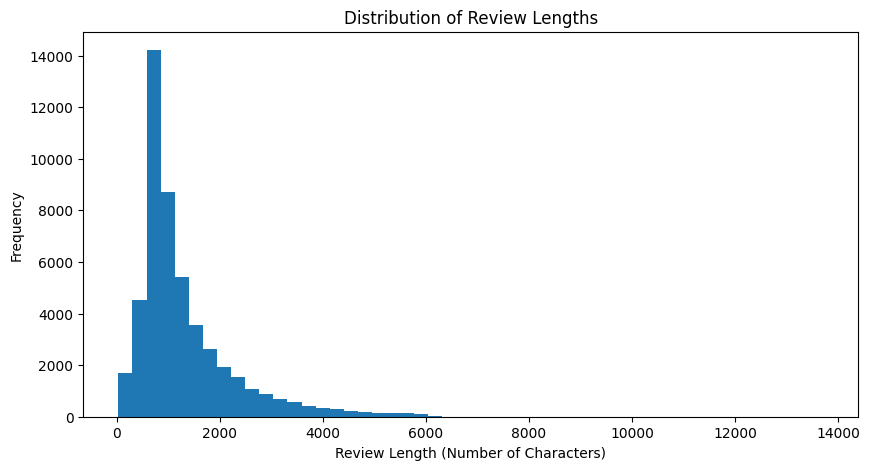

In [ ]:
# Feature Check: Investigate 'review' text
print("\n--- Investigating Feature ('review') ---")

# Create a new column for the length of each review
df['review_length'] = df['review'].apply(len)

print("Statistics for review length (df['review_length'].describe()):")
print(df['review_length'].describe())

# Plot a histogram to see the distribution of lengths (This step is optional)
print("\nPlotting histogram of review lengths...")
df['review_length'].plot(
    kind='hist',
    bins=50,
    title='Distribution of Review Lengths',
    figsize=(10, 5)
)
plt.xlabel('Review Length (Number of Characters)')
plt.show()